# Task 3.2: Failure Mode

**Failure scenario:** set the nonconvex threshold too aggressively to `s = 0.25` while keeping the rest of the training pipeline unchanged. I expected this to fail because the paper itself warns that positive `s` values can suppress even within-margin points, and in a single-pass online learner the earliest margin values are especially fragile.

In [1]:

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import accuracy_score, roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

SEEDS = [11, 23, 42, 57, 89]
DATA_NOISE = 0.22
LABEL_FLIP_RATE = 0.12
N_SAMPLES = 1200
TEST_SIZE = 0.20
VAL_SIZE = 0.20
GAMMA_GRID = [0.5, 1.0, 2.0]
SELECTED_GAMMA = 2.0
N_COMPONENTS = 500
LEARNING_RATE = 0.03
WEIGHT_DECAY = 1e-4
FULL_S = -1.0
FAILURE_S = 0.25
PAPER_BANANA_ACCURACY = 89.84

cwd = Path.cwd()
if (cwd / "results").exists() and (cwd / "data").exists():
    PARTB_DIR = cwd
elif (cwd / "partB").exists():
    PARTB_DIR = cwd / "partB"
else:
    PARTB_DIR = cwd
RESULTS_DIR = PARTB_DIR / "results"
DATA_DIR = PARTB_DIR / "data"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


def build_dataset(seed, label_flip_rate=LABEL_FLIP_RATE, data_noise=DATA_NOISE):
    X, y = make_moons(n_samples=N_SAMPLES, noise=data_noise, random_state=42)
    X_train, X_temp, y_train_clean, y_temp = train_test_split(
        X, y, test_size=TEST_SIZE + VAL_SIZE, stratify=y, random_state=seed
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=relative_test_size, stratify=y_temp, random_state=seed
    )

    rng = np.random.default_rng(seed)
    flip_count = int(label_flip_rate * len(y_train_clean))
    flip_idx = np.sort(rng.choice(len(y_train_clean), size=flip_count, replace=False))

    y_train_observed = y_train_clean.copy()
    y_train_observed[flip_idx] = 1 - y_train_observed[flip_idx]
    was_flipped = np.zeros(len(y_train_clean), dtype=bool)
    was_flipped[flip_idx] = True

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return {
        "seed": seed,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "X_train_scaled": X_train_scaled,
        "X_val_scaled": X_val_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train_clean": y_train_clean,
        "y_train_observed": y_train_observed,
        "y_val": y_val,
        "y_test": y_test,
        "was_flipped": was_flipped,
        "scaler": scaler,
    }


def validate_gamma(seeds=SEEDS, gammas=GAMMA_GRID, s=FULL_S):
    rows = []
    for gamma in gammas:
        for seed in seeds:
            split = build_dataset(seed)
            result = train_filtered_online_svm(
                split,
                gamma=gamma,
                s=s,
                n_components=N_COMPONENTS,
                learning_rate=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY,
            )
            rows.append({
                "gamma": gamma,
                "seed": seed,
                "val_accuracy": result["val_accuracy"],
                "val_auc": result["val_auc"],
            })
    frame = pd.DataFrame(rows)
    summary = frame.groupby("gamma", as_index=False).agg(
        mean_val_accuracy=("val_accuracy", "mean"),
        std_val_accuracy=("val_accuracy", "std"),
        mean_val_auc=("val_auc", "mean"),
    )
    return frame, summary


def decision_scores(artifacts, X_raw):
    X_scaled = artifacts["scaler"].transform(X_raw)
    Phi = artifacts["feature_map"].transform(X_scaled)
    return Phi @ artifacts["weights"]


def train_filtered_online_svm(
    split,
    gamma=SELECTED_GAMMA,
    s=FULL_S,
    n_components=N_COMPONENTS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    process_confident=False,
):
    feature_map = RBFSampler(gamma=gamma, n_components=n_components, random_state=split["seed"])
    Phi_train = feature_map.fit_transform(split["X_train_scaled"])
    Phi_val = feature_map.transform(split["X_val_scaled"])
    Phi_test = feature_map.transform(split["X_test_scaled"])

    y_pm = np.where(split["y_train_observed"] == 1, 1.0, -1.0)
    weights = np.zeros(Phi_train.shape[1], dtype=float)

    processed = 0
    skipped_left = 0
    skipped_right = 0

    start = time.perf_counter()
    for x_i, y_i in zip(Phi_train, y_pm):
        z = y_i * float(np.dot(weights, x_i))
        if z < s:
            skipped_left += 1
            continue
        if z > 1.0 and not process_confident:
            skipped_right += 1
            continue

        processed += 1
        weights *= (1.0 - learning_rate * weight_decay)
        if z <= 1.0:
            weights += learning_rate * y_i * x_i
    runtime = time.perf_counter() - start

    val_scores = Phi_val @ weights
    test_scores = Phi_test @ weights
    val_pred = (val_scores >= 0).astype(int)
    test_pred = (test_scores >= 0).astype(int)

    return {
        "seed": split["seed"],
        "gamma": gamma,
        "s": s,
        "process_confident": process_confident,
        "val_accuracy": accuracy_score(split["y_val"], val_pred),
        "val_auc": roc_auc_score(split["y_val"], val_scores),
        "test_accuracy": accuracy_score(split["y_test"], test_pred),
        "test_auc": roc_auc_score(split["y_test"], test_scores),
        "processed_examples": processed,
        "skipped_left": skipped_left,
        "skipped_right": skipped_right,
        "runtime_seconds": runtime,
        "weights": weights,
        "feature_map": feature_map,
        "scaler": split["scaler"],
        "split": split,
    }


def run_experiment(seeds=SEEDS, **kwargs):
    records = []
    artifacts = []
    for seed in seeds:
        split = build_dataset(seed)
        result = train_filtered_online_svm(split, **kwargs)
        records.append({
            "seed": seed,
            "test_accuracy": result["test_accuracy"],
            "test_auc": result["test_auc"],
            "processed_examples": result["processed_examples"],
            "skipped_left": result["skipped_left"],
            "skipped_right": result["skipped_right"],
            "runtime_seconds": result["runtime_seconds"],
        })
        artifacts.append(result)
    return pd.DataFrame(records), artifacts


def summarise_results(label, frame):
    return pd.DataFrame([
        {
            "method": label,
            "accuracy_mean": frame["test_accuracy"].mean(),
            "accuracy_std": frame["test_accuracy"].std(ddof=0),
            "auc_mean": frame["test_auc"].mean(),
            "auc_std": frame["test_auc"].std(ddof=0),
            "processed_mean": frame["processed_examples"].mean(),
            "processed_std": frame["processed_examples"].std(ddof=0),
            "runtime_mean": frame["runtime_seconds"].mean(),
            "runtime_std": frame["runtime_seconds"].std(ddof=0),
        }
    ])


def comparison_barplot(frame, metric_cols, title, output_path):
    melted = frame.melt(id_vars="method", value_vars=metric_cols, var_name="metric", value_name="value")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(data=melted, x="metric", y="value", hue="method", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Value")
    ax.legend(title="Method")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def save_seed42_dataset_csv(output_path):
    split = build_dataset(42)
    train_frame = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    train_frame["split"] = "train"
    train_frame["clean_label"] = split["y_train_clean"]
    train_frame["observed_label"] = split["y_train_observed"]
    train_frame["was_flipped"] = split["was_flipped"]

    val_frame = pd.DataFrame(split["X_val"], columns=["x1", "x2"])
    val_frame["split"] = "val"
    val_frame["clean_label"] = split["y_val"]
    val_frame["observed_label"] = split["y_val"]
    val_frame["was_flipped"] = False

    test_frame = pd.DataFrame(split["X_test"], columns=["x1", "x2"])
    test_frame["split"] = "test"
    test_frame["clean_label"] = split["y_test"]
    test_frame["observed_label"] = split["y_test"]
    test_frame["was_flipped"] = False

    full_frame = pd.concat([train_frame, val_frame, test_frame], ignore_index=True)
    full_frame.to_csv(output_path, index=False)
    return full_frame


def plot_dataset_overview(split, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    clean_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    clean_train["label"] = split["y_train_clean"]
    sns.scatterplot(data=clean_train, x="x1", y="x2", hue="label", palette="Set1", s=35, ax=axes[0])
    axes[0].set_title("Seed 42 training set before label flips")

    noisy_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    noisy_train["observed_label"] = split["y_train_observed"]
    noisy_train["was_flipped"] = split["was_flipped"]
    sns.scatterplot(
        data=noisy_train,
        x="x1",
        y="x2",
        hue="observed_label",
        style="was_flipped",
        palette="Set1",
        s=35,
        ax=axes[1],
    )
    axes[1].set_title("Seed 42 training set after 12% label flips")

    for ax in axes:
        ax.set_xlabel("feature 1")
        ax.set_ylabel("feature 2")

    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def plot_decision_surface(artifacts, output_path, title):
    split = artifacts["split"]
    X_all = np.vstack([split["X_train"], split["X_test"]])
    y_all = np.concatenate([split["y_train_observed"], split["y_test"]])

    x_min, x_max = X_all[:, 0].min() - 0.4, X_all[:, 0].max() + 0.4
    y_min, y_max = X_all[:, 1].min() - 0.4, X_all[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
    grid = np.c_[xx.ravel(), yy.ravel()]
    scores = decision_scores(artifacts, grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    classes = (scores >= 0).astype(float)
    ax.contourf(xx, yy, classes, levels=[-0.1, 0.5, 1.1], alpha=0.22, cmap="coolwarm")
    if np.ptp(scores) > 1e-9:
        ax.contour(xx, yy, scores, levels=[0.0], colors="black", linewidths=1.2)

    ax.scatter(split["X_train"][:, 0], split["X_train"][:, 1], c=split["y_train_observed"], cmap="coolwarm", s=22, alpha=0.75, label="Train")
    ax.scatter(split["X_test"][:, 0], split["X_test"][:, 1], c=split["y_test"], cmap="coolwarm", s=28, marker="x", label="Test")
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


The same code base is reused here so that the failure is tied to one design choice only: the value of `s`. This makes the failure easy to connect back to the assumptions I wrote in Task 1.2.

In [2]:
full_runs, full_artifacts = run_experiment(gamma=SELECTED_GAMMA, s=FULL_S, process_confident=False)
failure_runs, failure_artifacts = run_experiment(gamma=SELECTED_GAMMA, s=FAILURE_S, process_confident=False)
failure_compare = pd.concat([
    summarise_results('Full method (s = -1)', full_runs),
    summarise_results('Failure setting (s = 0.25)', failure_runs),
], ignore_index=True)
failure_compare

                       method  accuracy_mean  ...  runtime_mean  runtime_std
0        Full method (s = -1)           0.92  ...      0.001125     0.000027
1  Failure setting (s = 0.25)           0.50  ...      0.000414     0.000014

[2 rows x 9 columns]

This code shows the failure numerically. Because the initial model starts at zero and the rule says skip any point with `z < s`, making `s` positive can stop learning before it even begins, which is exactly the kind of brittleness that a nonconvex filter can introduce.

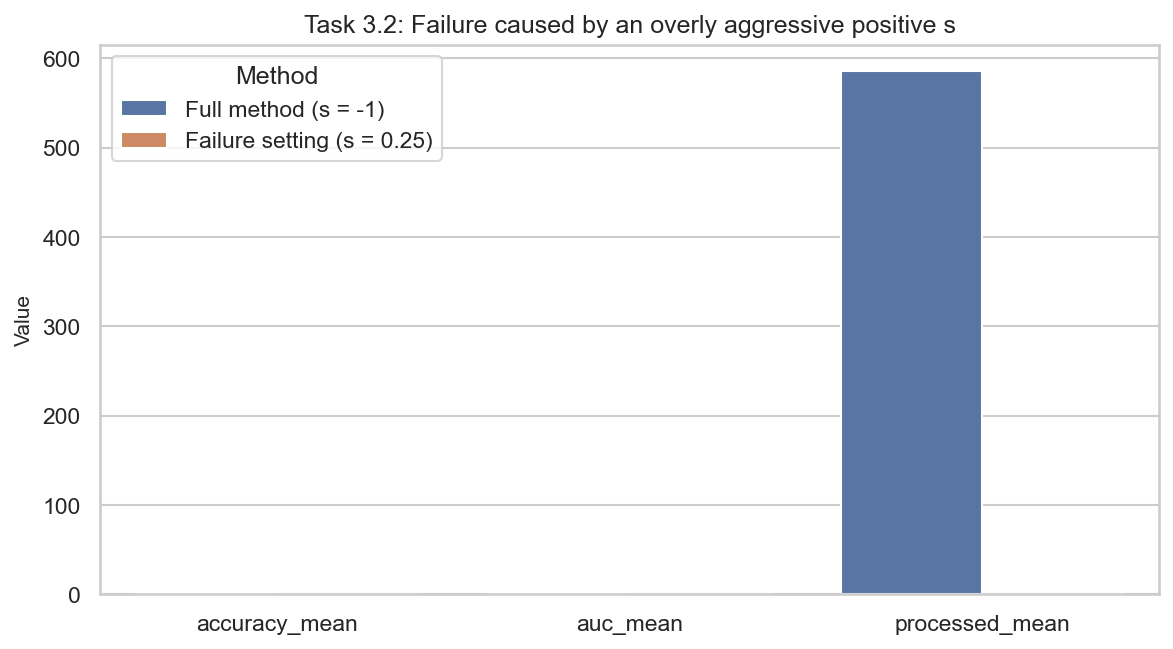

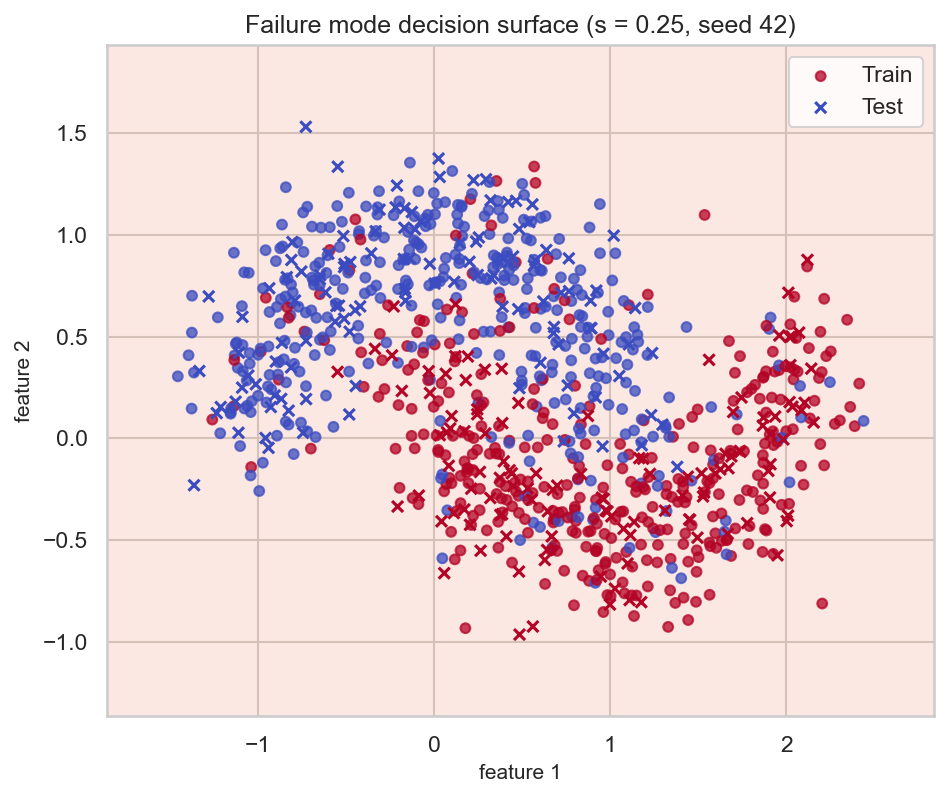

In [3]:
comparison_barplot(
    failure_compare[['method', 'accuracy_mean', 'auc_mean', 'processed_mean']],
    ['accuracy_mean', 'auc_mean', 'processed_mean'],
    'Task 3.2: Failure caused by an overly aggressive positive s',
    RESULTS_DIR / 'task_3_2_failure_metrics.png',
)
seed42_failure = next(item for item in failure_artifacts if item['seed'] == 42)
plot_decision_surface(seed42_failure, RESULTS_DIR / 'task_3_2_failure_boundary.png', 'Failure mode decision surface (s = 0.25, seed 42)')

The plots make the failure more concrete. In this case the learner effectively freezes, so the decision surface becomes trivial and the test accuracy drops to chance level.

**Why the method fails here:** This failure is a direct consequence of Assumption 1 from Task 1.2. LASVM-I assumes the current model is already reliable enough to judge which points are too far on the wrong side to be useful. With `s = 0.25`, that assumption collapses immediately because the model has not learned anything yet, but the filter is already active. So instead of rejecting true outliers, the method rejects almost the entire training stream. This also connects to the paper's discussion that positive `s` can prevent informative samples from ever becoming support vectors. My experiment exaggerates that effect, but it is still the same structural weakness.

**One concrete modification:** I would address this by using an adaptive schedule for `s`, starting with a permissive negative value and only tightening the filter after the model has seen enough data to make reliable margin judgments.